## importing libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from keras.layers import Dense, BatchNormalization, Dropout, LSTM
from keras.models import Sequential
from keras.utils import to_categorical
from keras import callbacks
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score

## Loading Data

In [3]:
data=pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
data.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


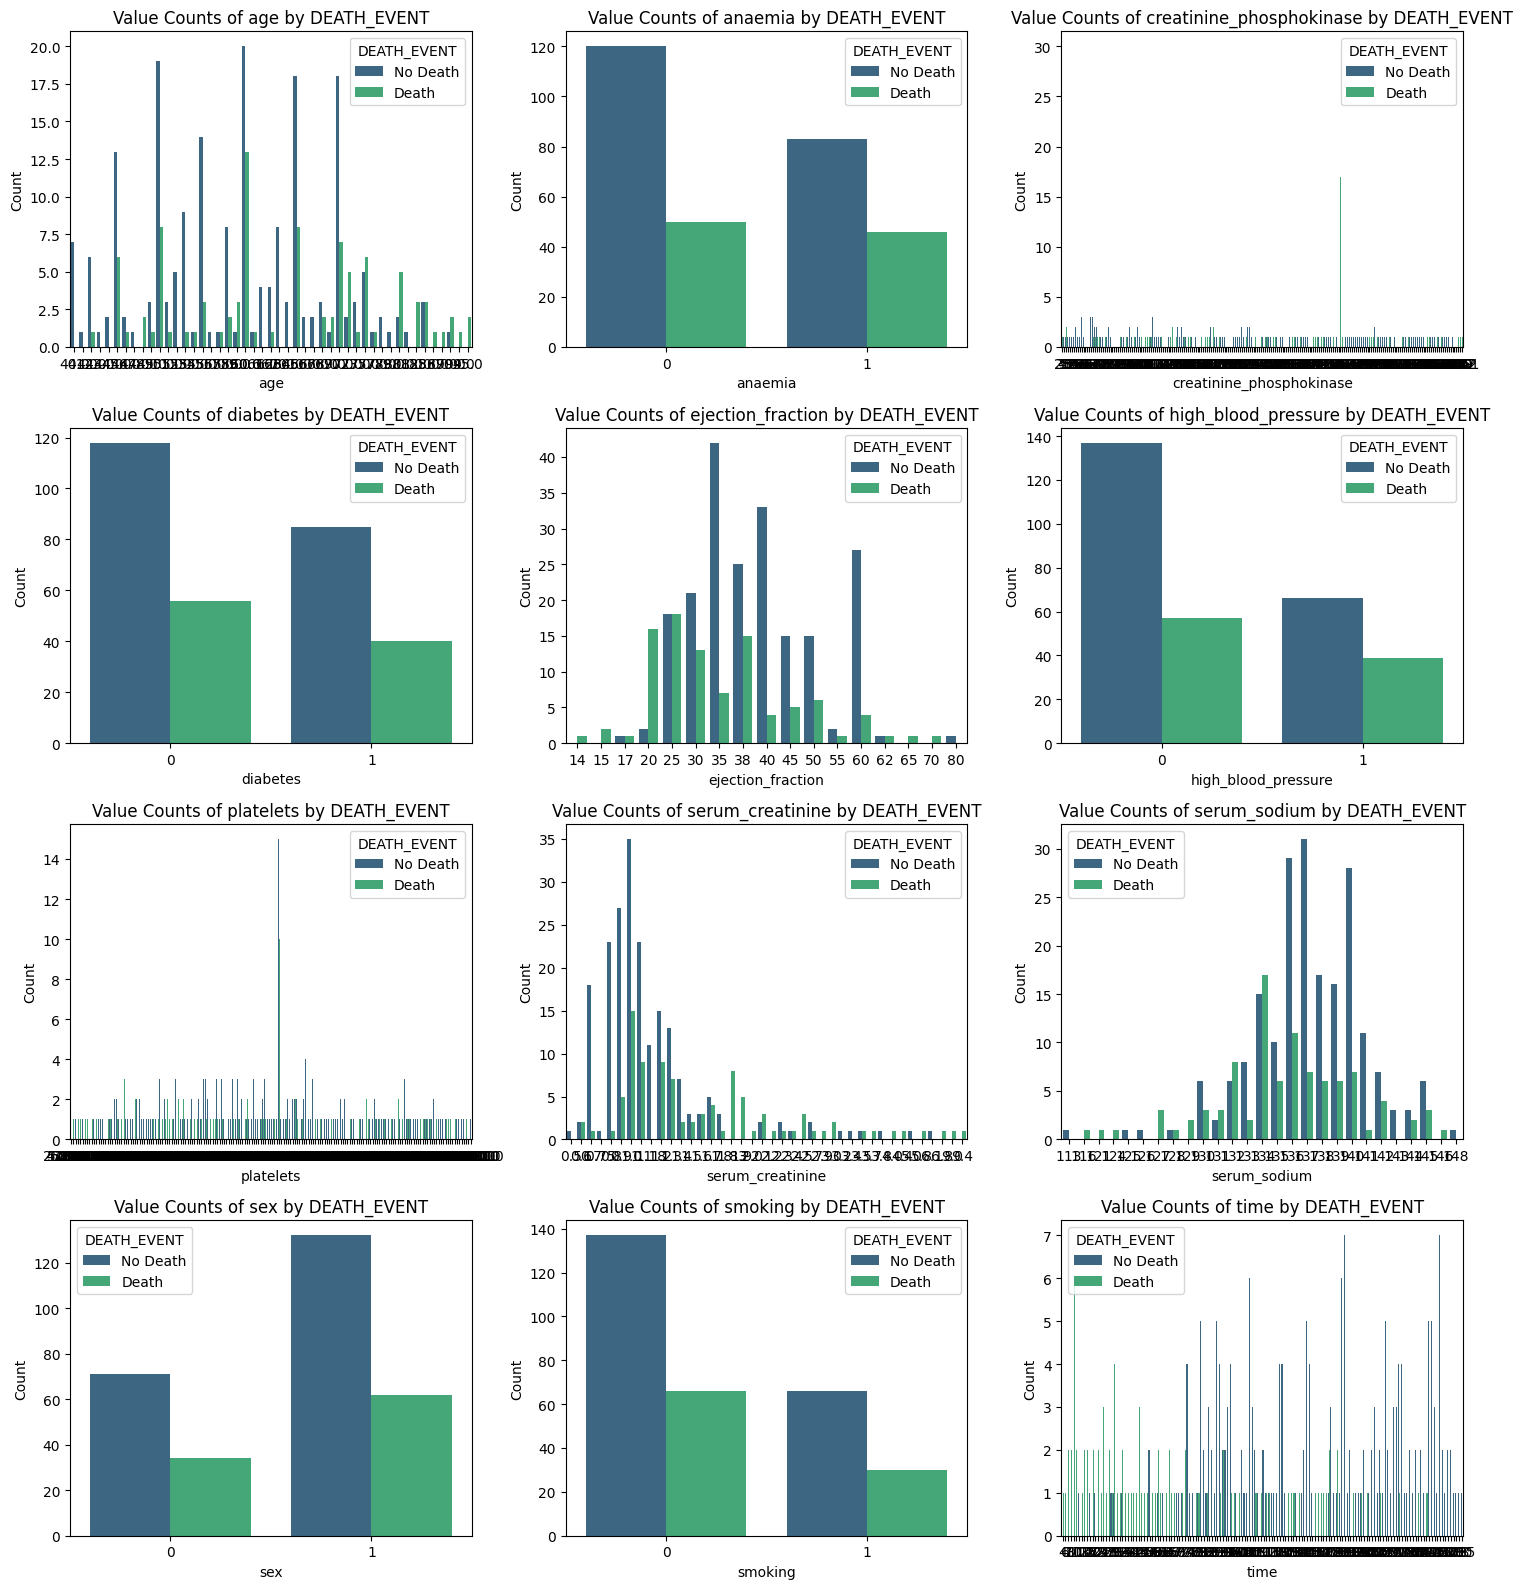

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all feature columns except the target 'DEATH_EVENT'
feature_columns = data.columns.drop('DEATH_EVENT')

# Determine the number of rows and columns for the subplots
num_features = len(feature_columns)
num_cols = 3 # You can adjust this number
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, column in enumerate(feature_columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(data=data, x=column, hue='DEATH_EVENT', palette='viridis')
    plt.title(f'Value Counts of {column} by DEATH_EVENT')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='DEATH_EVENT', labels=['No Death', 'Death'])

plt.tight_layout()
plt.show()

## Check balanced or imbalanced Data

In [6]:
death_event_counts = data['DEATH_EVENT'].value_counts()
print(death_event_counts)


DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


## Correlation Matrix

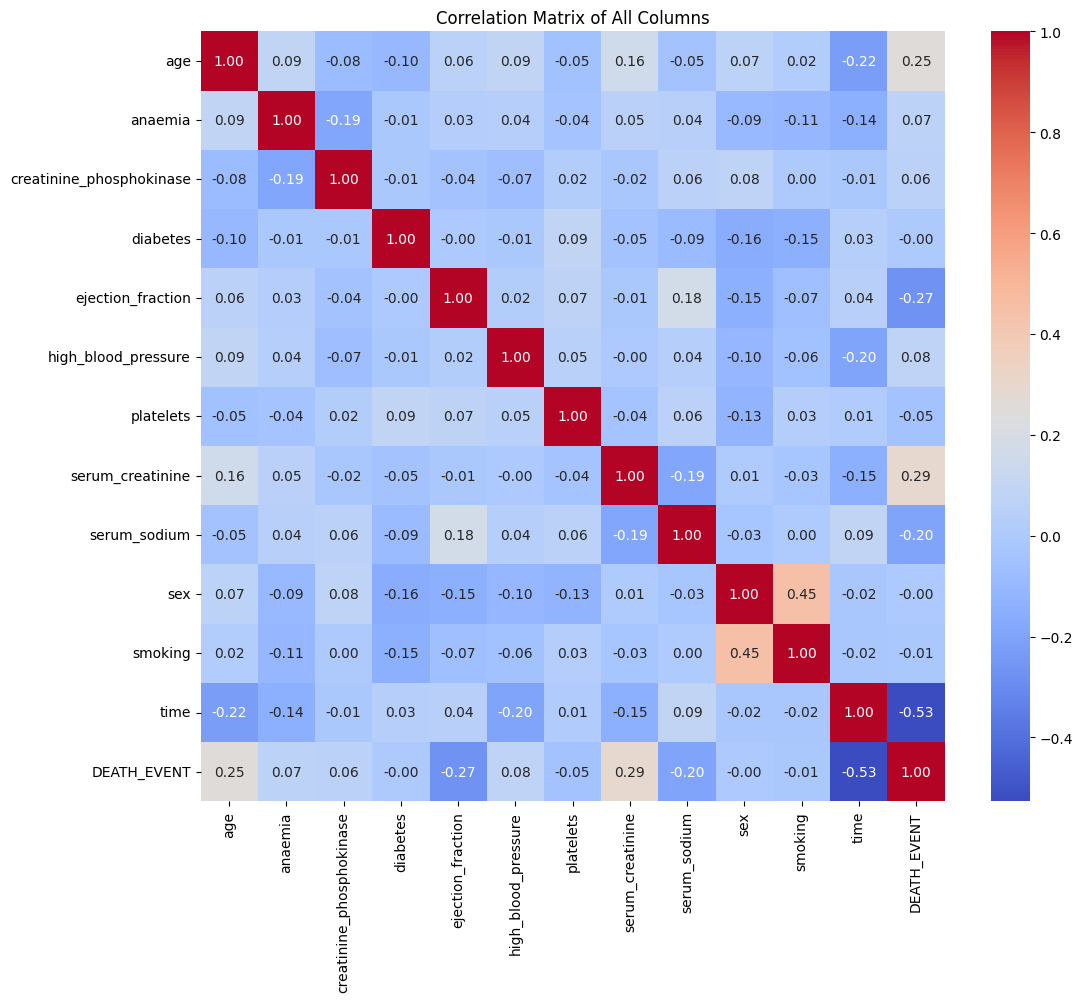

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Columns')
plt.show()

In [8]:
correlations = data.corr()['DEATH_EVENT'].abs().sort_values(ascending=False)
print("Top features correlated with DEATH_EVENT:")
print(correlations)

Top features correlated with DEATH_EVENT:
DEATH_EVENT                 1.000000
time                        0.526964
serum_creatinine            0.294278
ejection_fraction           0.268603
age                         0.253729
serum_sodium                0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
platelets                   0.049139
smoking                     0.012623
sex                         0.004316
diabetes                    0.001943
Name: DEATH_EVENT, dtype: float64


## Check for outliers

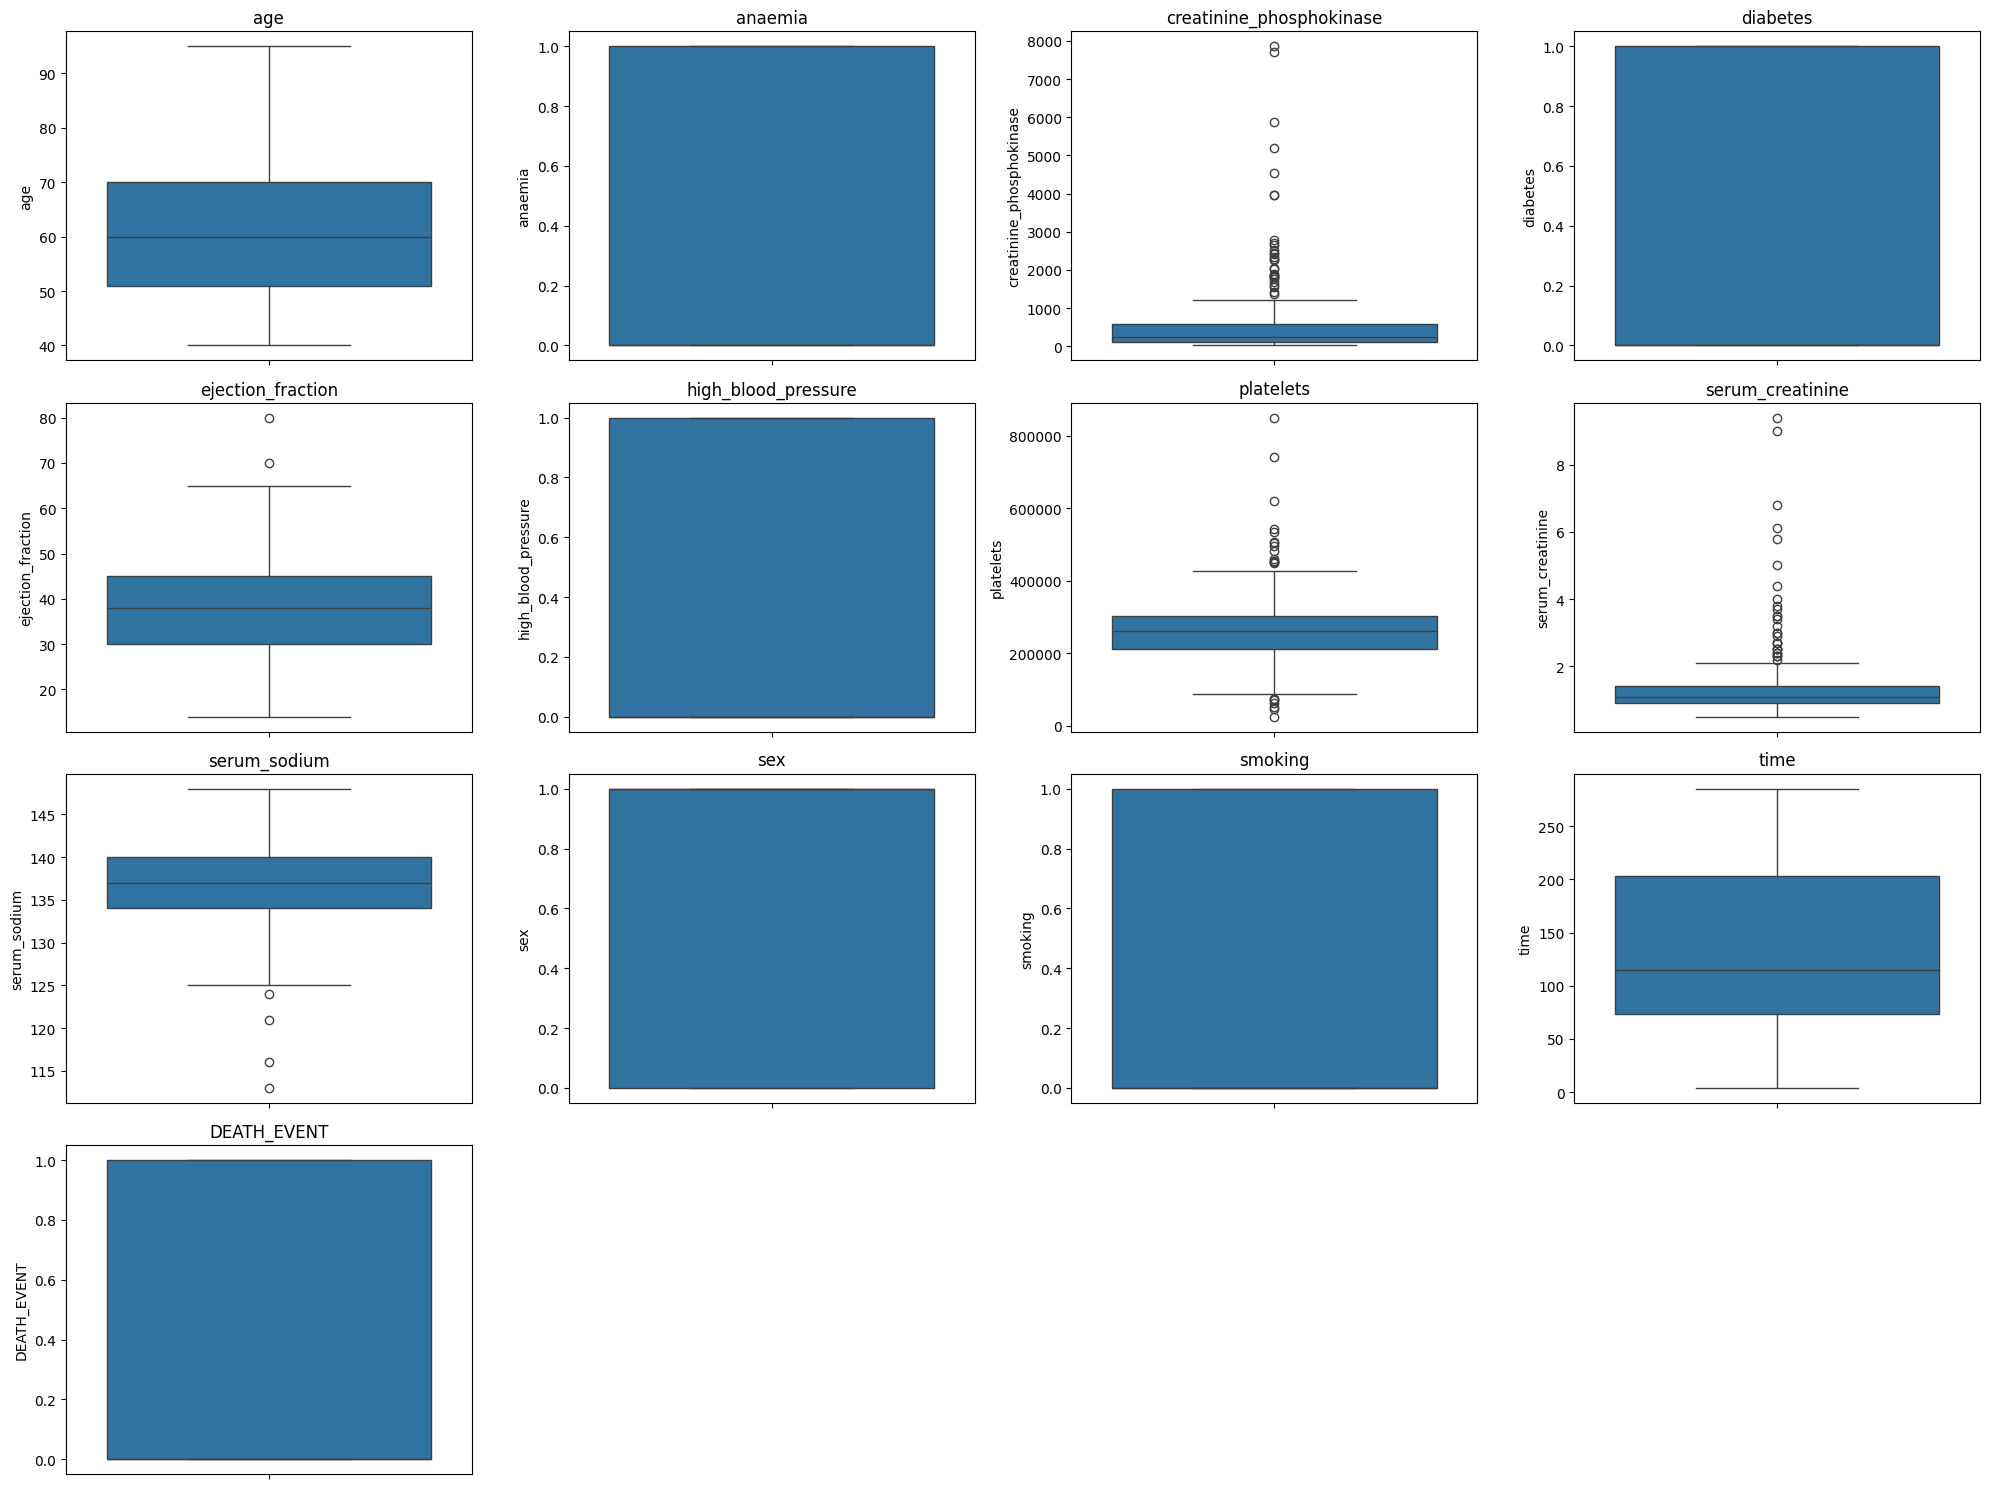

In [9]:
plt.figure(figsize=(20, 15))
for i, column in enumerate(data.columns):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=data[column])
    plt.title(column)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [10]:
X=data.drop(columns='DEATH_EVENT',axis=1)
y=data['DEATH_EVENT']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional, but good for understanding)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("X_train after scaling (first 5 rows):")
print(X_train.head())
print("\nX_test after scaling (first 5 rows):")
print(X_test.head())

X_train after scaling (first 5 rows):
        age   anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  1.164202  1.139332                 -0.350370 -0.826498          -2.000867   
1  1.164202 -0.877707                 -0.505933 -0.826498          -0.022672   
2 -0.032819  1.139332                 -0.500642  1.209925          -0.710740   
3 -0.756645 -0.877707                 -0.471011 -0.826498          -0.710740   
4  2.750989 -0.877707                  0.005203  1.209925          -0.022672   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium       sex  \
0            -0.736163  -1.439568         -0.188705      0.131259  0.742932   
1             1.358395  -0.408476          1.120602     -0.545811  0.742932   
2            -0.736163   1.345442          0.113442     -0.094431  0.742932   
3            -0.736163  -0.472255         -0.692285     -0.094431  0.742932   
4             1.358395   0.009892          0.445805     -0.545811  0.742932   

    sm

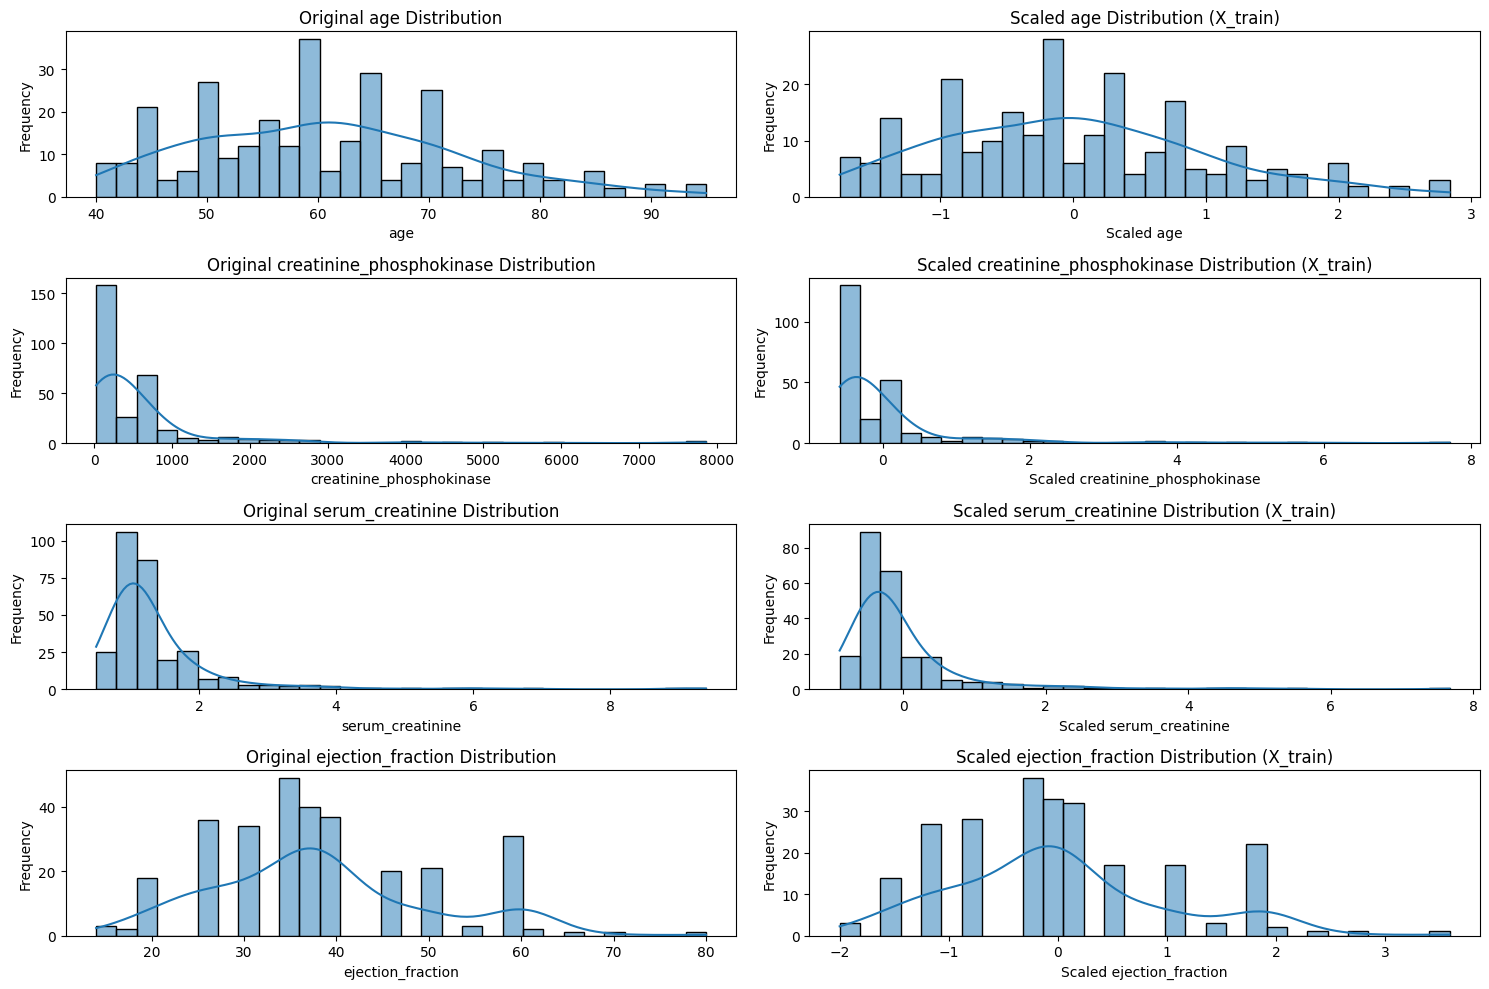

In [13]:
selected_features = ['age', 'creatinine_phosphokinase', 'serum_creatinine', 'ejection_fraction']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(selected_features):
    # Plot original data distribution
    plt.subplot(len(selected_features), 2, 2*i + 1)
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f'Original {feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Plot scaled data distribution
    plt.subplot(len(selected_features), 2, 2*i + 2)
    sns.histplot(X_train[feature], kde=True, bins=30)
    plt.title(f'Scaled {feature} Distribution (X_train)')
    plt.xlabel(f'Scaled {feature}')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

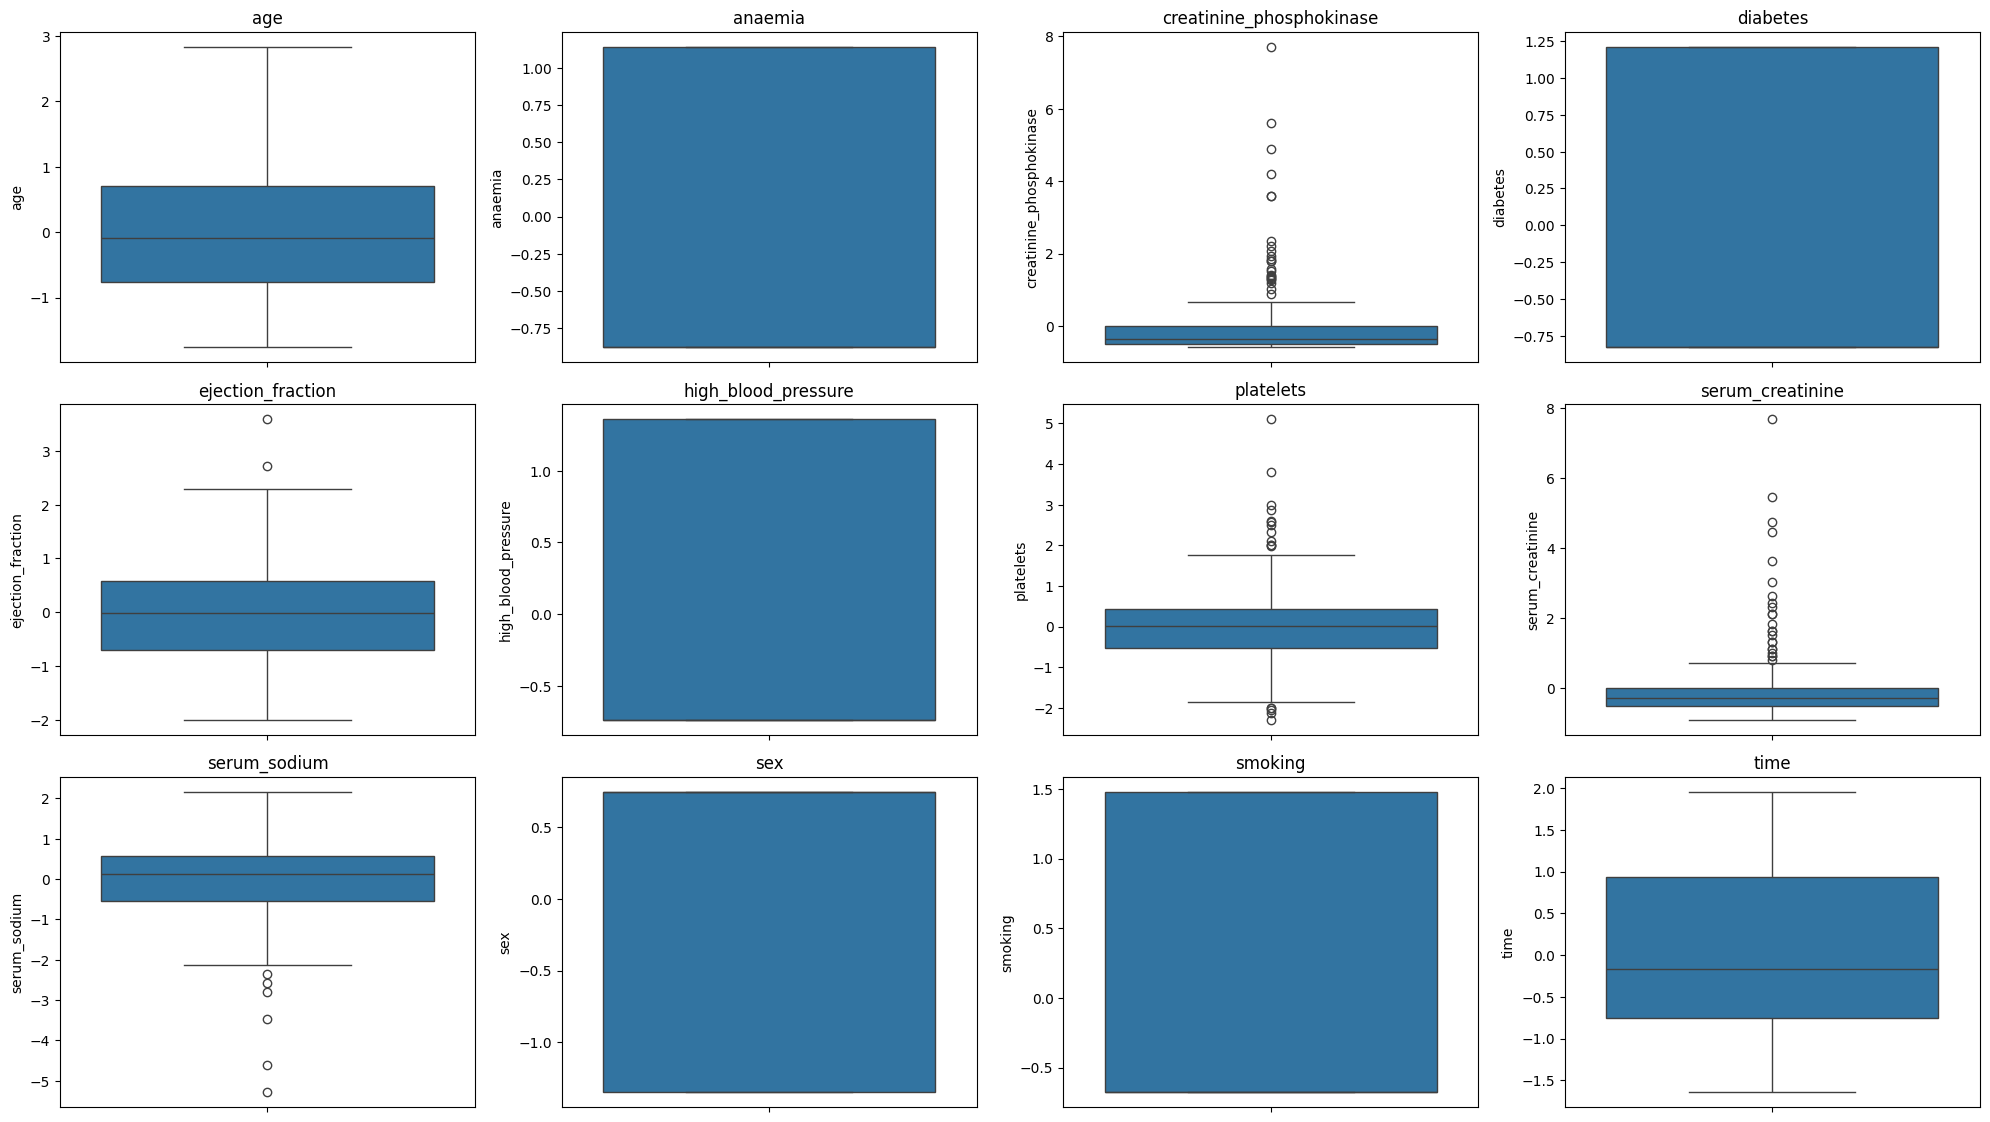

In [14]:
plt.figure(figsize=(20, 15))
for i, column in enumerate(X_train.columns):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=X_train[column])
    plt.title(column)
plt.tight_layout()
plt.show()

In [15]:
outliers_count = {}
for column in X_train.columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    num_outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)].shape[0]
    outliers_count[column] = num_outliers

print("Total number of outliers in each column of X_train:")
for column, count in outliers_count.items():
    print(f"Column '{column}': {count} outliers")

Total number of outliers in each column of X_train:
Column 'age': 0 outliers
Column 'anaemia': 0 outliers
Column 'creatinine_phosphokinase': 24 outliers
Column 'diabetes': 0 outliers
Column 'ejection_fraction': 2 outliers
Column 'high_blood_pressure': 0 outliers
Column 'platelets': 17 outliers
Column 'serum_creatinine': 23 outliers
Column 'serum_sodium': 6 outliers
Column 'sex': 0 outliers
Column 'smoking': 0 outliers
Column 'time': 0 outliers


In [16]:
for column, num_outliers in outliers_count.items():
    if num_outliers > 0:
        Q1 = X_train[column].quantile(0.25)
        Q3 = X_train[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Calculate the mean of the column
        column_mean = X_train[column].mean()

        # Replace outliers with the mean
        X_train.loc[(X_train[column] < lower_bound) | (X_train[column] > upper_bound), column] = column_mean
        print(f"Outliers in '{column}' replaced with mean value: {column_mean:.2f}")

print("\nOutlier replacement complete for X_train.")

Outliers in 'creatinine_phosphokinase' replaced with mean value: -0.00
Outliers in 'ejection_fraction' replaced with mean value: -0.00
Outliers in 'platelets' replaced with mean value: -0.00
Outliers in 'serum_creatinine' replaced with mean value: -0.00
Outliers in 'serum_sodium' replaced with mean value: -0.00

Outlier replacement complete for X_train.


In [17]:
model=Sequential()
model.add(Dense(32,activation='relu',input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(16,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 96 (384.00 B)

### Model Training

Now, let's train the ANN model using the `X_train` and `y_train` data. We will also use a `validation_split` to monitor the model's performance on a portion of the training data that it hasn't seen during direct training, which helps in detecting overfitting.

In [18]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

print("\nModel training complete.")

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5393 - loss: 0.9093 - val_accuracy: 0.7292 - val_loss: 0.6126
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5183 - loss: 0.8342 - val_accuracy: 0.7083 - val_loss: 0.6090
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5026 - loss: 0.8608 - val_accuracy: 0.6875 - val_loss: 0.6057
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5707 - loss: 0.7910 - val_accuracy: 0.6875 - val_loss: 0.6025
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5183 - loss: 0.7983 - val_accuracy: 0.7083 - val_loss: 0.5977
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5654 - loss: 0.7680 - val_accuracy: 0.7292 - val_loss: 0.5934
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5445 - loss: 0.7566 - val_accuracy: 0.7292 - val_loss: 0.5885
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6230 - loss: 0.6533 - val_accuracy: 0.7292 - val_loss: 0.5840


### Visualize Training History

Let's plot the training and validation accuracy and loss over the epochs to better understand the model's learning process.

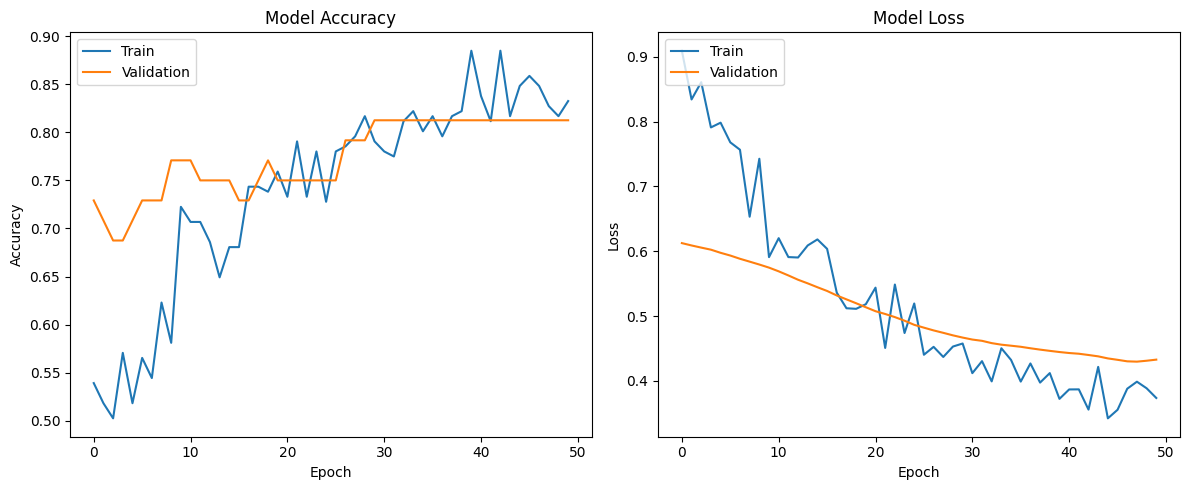

In [19]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization

# Reshape input data for LSTM layers: (samples, timesteps, features)
# Here, we treat each feature as a timestep and each timestep has 1 feature.
X_train_rnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_rnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train_rnn shape: {X_train_rnn.shape}")
print(f"X_test_rnn shape: {X_test_rnn.shape}")

# Define the RNN model
rnn_model = Sequential()
rnn_model.add(LSTM(64, return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)))
rnn_model.add(BatchNormalization())
rnn_model.add(Dropout(0.3))
rnn_model.add(LSTM(32, return_sequences=False))
rnn_model.add(BatchNormalization())
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
rnn_model.summary()

print("\nTraining the RNN model...")
rnn_history = rnn_model.fit(X_train_rnn, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

print("\nRNN Model training complete.")

X_train_rnn shape: (239, 12, 1)
X_test_rnn shape: (60, 12, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,729 (116.13 KB)

 Trainable params: 29,537 (115.38 KB)

 Non-trainable params: 192 (768.00 B)


Training the RNN model...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.5079 - loss: 0.8832 - val_accuracy: 0.7500 - val_loss: 0.6736
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5812 - loss: 0.8106 - val_accuracy: 0.7500 - val_loss: 0.6617
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6178 - loss: 0.6995 - val_accuracy: 0.7500 - val_loss: 0.6538
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6230 - loss: 0.6991 - val_accuracy: 0.7500 - val_loss: 0.6457
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5654 - loss: 0.7380 - val_accuracy: 0.7500 - val_loss: 0.6389
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5916 - loss: 0.7111 - val_accuracy: 0.7500 - val_loss: 0.6329
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6649 - loss: 0.6528 - val_accuracy: 0.7500 - val_loss: 0.6278
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7225 - loss: 0.5568 - val_accuracy

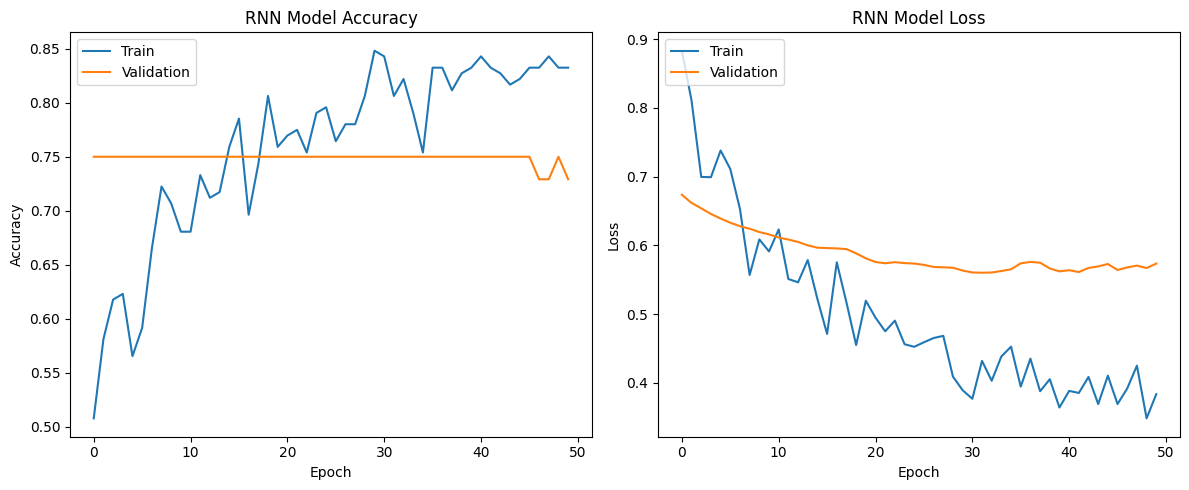

In [22]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.title('RNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.title('RNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


Evaluating the RNN model...
RNN Test Loss: 0.6918
RNN Test Accuracy: 0.5833
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step

RNN Classification Report:
              precision    recall  f1-score   support

           0       0.58      1.00      0.74        35
           1       0.00      0.00      0.00        25

    accuracy                           0.58        60
   macro avg       0.29      0.50      0.37        60
weighted avg       0.34      0.58      0.43        60


RNN Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


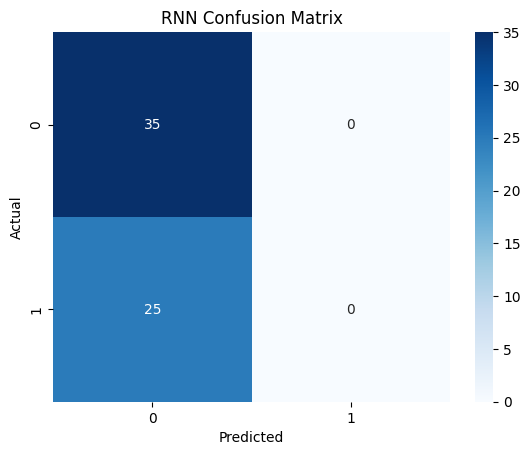

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("\nEvaluating the RNN model...")

rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_rnn, y_test, verbose=0)
print(f"RNN Test Loss: {rnn_loss:.4f}")
print(f"RNN Test Accuracy: {rnn_accuracy:.4f}")

y_pred_rnn = (rnn_model.predict(X_test_rnn) > 0.5).astype("int32")

print("\nRNN Classification Report:")
print(classification_report(y_test, y_pred_rnn))

print("\nRNN Confusion Matrix:")
conf_matrix_rnn = confusion_matrix(y_test, y_pred_rnn)
sns.heatmap(conf_matrix_rnn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RNN Confusion Matrix')
plt.show()


In [23]:
import gradio as gr
import pandas as pd

# Define the prediction function for the ANN model
def predict_death_event_ann(
    age,
    anaemia,
    creatinine_phosphokinase,
    diabetes,
    ejection_fraction,
    high_blood_pressure,
    platelets,
    serum_creatinine,
    serum_sodium,
    sex,
    smoking,
    time
):
    # Create a DataFrame from the input values
    input_data = pd.DataFrame([[age, anaemia, creatinine_phosphokinase, diabetes,
                                  ejection_fraction, high_blood_pressure, platelets,
                                  serum_creatinine, serum_sodium, sex, smoking, time]],
                                columns=X.columns) # Use original column names from X

    # Scale the input data using the already fitted scaler
    scaled_input = scaler.transform(input_data)

    # Convert back to DataFrame (optional, but good practice if model expects DataFrame)
    scaled_input_df = pd.DataFrame(scaled_input, columns=X.columns)

    # Predict using the trained ANN model
    prediction = model.predict(scaled_input_df)[0][0]

    # Convert prediction to a human-readable format
    if prediction >= 0.5:
        return f"Prediction: Death Event (Probability: {prediction:.2f})"
    else:
        return f"Prediction: No Death Event (Probability: {prediction:.2f})"

# Create Gradio Interface
inputs = [
    gr.Number(label="Age"),
    gr.Radio([0, 1], label="Anaemia (0=No, 1=Yes)"),
    gr.Number(label="Creatinine Phosphokinase"),
    gr.Radio([0, 1], label="Diabetes (0=No, 1=Yes)"),
    gr.Number(label="Ejection Fraction (%)"),
    gr.Radio([0, 1], label="High Blood Pressure (0=No, 1=Yes)"),
    gr.Number(label="Platelets"),
    gr.Number(label="Serum Creatinine"),
    gr.Number(label="Serum Sodium"),
    gr.Radio([0, 1], label="Sex (0=Female, 1=Male)"),
    gr.Radio([0, 1], label="Smoking (0=No, 1=Yes)"),
    gr.Number(label="Time (days)")
]

output = gr.Textbox(label="Prediction")

iface = gr.Interface(
    fn=predict_death_event_ann,
    inputs=inputs,
    outputs=output,
    title="Heart Failure Prediction (ANN Model)",
    description="Enter patient details to predict the likelihood of a death event.",
    live=False
)

# Launch the Gradio app
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://900e3e112db7da403f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
